In [ ]:
# default_exp core.baseline

In [ ]:
#hide
from nbdev.showdoc import *

In [ ]:
#export
import scipy.sparse as sparse
from scipy.sparse import linalg
from numpy.linalg import norm
import numpy as np
import scipy.interpolate as interp
from scipy import ndimage
from scipy import optimize
from hifast.utils.misc import average_every_n, smooth1d, smooth1d_fft

import os
import warnings 
warnings.filterwarnings("ignore", r'overflow encountered in exp')

In [ ]:
#export
def get_baseline(x, ys, axis=None, *, s_method=None, s_sigma=None, average_every=None, exclude=None, verbose=False, method='arPLS', bl_para=None, return_f=False, check=True):
    """ 
    subtract the baseline of spectra with XX and YY polar.
    Parameters：
    ---------------
    x: array, shape (n,); freq or vel. 
    ys: array, T or Jy
    axis: axis along fitting baseline
    s_sigma, s_method: if s_sigma is not None, smoothing ys along axis using s_method ('gaussian' or 'boxcar')
    return_f: If Fasle, return baseline, else return (basline, ys_processed, x_processed, weights)
    """
    if exclude is not None:
        if exclude.shape != ys.shape:
            raise(ValueError('exclude should has same shape with ys'))
    # check if ys is one dim      
    if ys.ndim == 1:
        ys = ys[:, None]
        if exclude is not None:
            exclude = exclude[:, None]
        ch = True
        axis = 0
    else:
        ch = False
    
    # smooth ys along axis
    if s_sigma is not None and s_method is not None:
        if s_method in ['boxcar', 'gaussian', 'median']:
            ys = smooth1d(ys, s_method, s_sigma, axis=axis)
        elif s_method == 'fft':
            ys = smooth1d_fft(x, ys, s_sigma, axis=axis)
        else:
            raise(ValueError('not support the method'))
    else:
        ys = ys
    
    if average_every is not None and average_every !=0:
        drop = False
        x_ori = x
        x = average_every_n(x, average_every, drop=drop)
        ys = average_every_n(ys, average_every, axis=axis, drop=drop)
        if exclude is not None:
            exclude = average_every_n(exclude, average_every, axis=axis, drop=drop).astype('bool')
    # after smooth(average), check nan, posinf, neginf
    if check:
        is_finite = np.isfinite(ys)
        if not is_finite.all():
            # replace value as 0 and add to exclude
            ys = np.copy(ys)
            ys[~is_finite] = 0.
            if exclude is not None:
                exclude = exclude | (~is_finite)
            else:
                exclude = ~is_finite
        del is_finite
    # select baseline method
    if method == 'arPLS':
        if 'sym' in bl_para.keys():
            bl_para = bl_para.copy() # shallow copy
            del bl_para['sym']
        BL = BL_arPLS(**bl_para)
        use_x = False
    elif method == 'asPLS':
        if 'sym' in bl_para.keys():
            bl_para = bl_para.copy() # shallow copy
            del bl_para['sym']
        BL = BL_asPLS(**bl_para)
        use_x = False
    elif method == 'srPLS':
        if 'sym' in bl_para.keys():
            bl_para = bl_para.copy() # shallow copy
            del bl_para['sym']
        BL = BL_srPLS(**bl_para)
        use_x = False
    elif method == 'Chebyshev':
        BL = BL_Chebyshev(**bl_para)
        use_x = True
    elif method == 'poly':
        BL = BL_poly(**bl_para)
        use_x = True
    elif method == 'sin_poly':
        BL = BL_sin_poly(**bl_para)
        use_x = True
    elif method == 'sin_poly_2':
        BL = BL_sin_poly_2(**bl_para)
        use_x = True
    elif method == 'original':
        return ys
    else:
        raise(ValueError('method does not support'))
    
    # move axis to last
    ys = np.moveaxis(ys, axis, -1)
    if exclude is not None:
        exclude = np.moveaxis(exclude, axis, -1)
    shape_bak = ys.shape
    #ys = ys.reshape((-1,shape_bak[-1])) #will copy the data
    #or np.apply_along_axis
    bls = np.zeros_like(ys)
    if return_f:
        weis = np.zeros_like(ys,dtype=np.float32)
    if verbose:
        from tqdm import tqdm
        iter_ = tqdm(np.ndindex(*(shape_bak[:-1])), total=ys.size/shape_bak[-1], desc='CPU 0: ', mininterval=2)
    else:
        iter_= np.ndindex(*(shape_bak[:-1]))
 
    for ii in iter_:
        y = ys[ii+ np.s_[:,]]
        if exclude is not None:
            _exclude = exclude[ii+ np.s_[:,]]
        else:
            _exclude = None
        if use_x:
            bl = BL.fit(x, y, _exclude)
        else:
            bl = BL.fit(y, _exclude)
        bls[ii+ np.s_[:,]] = bl
        if return_f:
            weis[ii+ np.s_[:,]] = BL.wei
    # move back
    bls = np.moveaxis(bls,-1,axis)
    if return_f:
            weis = np.moveaxis(weis,-1,axis)
    if average_every is not None:
        bls = interp.interp1d(x, bls, axis=axis, kind='linear', fill_value ='extrapolate')(x_ori)
    if return_f:
        # move back
        ys = np.moveaxis(ys, -1, axis)
        if ch:
            return bls[:,0], ys[:,0], x, weis[:,0]
        else:
            return bls, ys, x, weis
    else:
        if ch:
            return bls[:,0]
        else:
            return bls

def get_baseline_mp(n, x, ys, *, exclude=None,  **kwargs):
    """
    testing...
    only support axis=1, 
    not support return_f=True
    """
    from functools import partial
    from multiprocessing import Process, Queue
    def get_baseline_q(q, *args, **kwargs):
        res = get_baseline(*args, **kwargs)
        q.put(res)
    ps = []
    qs = []
    if exclude is not None:
        exclude_list = np.array_split(exclude, n)
    else:
        exclude_list = [None,] * n
    ys_list = np.array_split(ys, n)
    for ys, exclude in zip(ys_list, exclude_list):
        q = Queue()
        p = Process(target=get_baseline_q, args=(q, x, ys), kwargs={'exclude':exclude, **kwargs})
        if 'verbose' in kwargs.keys():
            kwargs['verbose']=False

        ps+= [p] 
        qs+= [q] 
    for p in ps:
        p.start()
    res = np.vstack([q.get()for q in qs])
    for p in ps:
        p.join() # need after q.get()
    return np.stack(res)


In [ ]:
#export
class BL_arPLS(object):
    """
    (automatic) Baseline correction using asymmetrically reweighted penalized least squares smoothing. 
                     Baek et al. 2015, Analyst 140: 250-257
    Parameters
    ----------
    lam:
    offset:
    deg:
    ratio:
    niter:
    """
    def __init__(self, lam=10**12, offset=2, deg=3, ratio=0.01, niter=100, rew=True):
        self.lam = lam
        self.offset = offset
        self.deg = deg
        self.ratio = ratio
        self.niter = niter
        if not rew : self.niter = 1
    def _reweight(self, d):
        # make d- and get w^t with m and s
        dn = d[d<0]
        m = np.mean(dn)
        s = np.std(dn)
        wt = 1.0/(1 + np.exp( 2* (d-(self.offset*s-m))/s ))
        return wt
    
    def fit(self, y, exclude=None, wei=None):
        # Adaptation of the Matlab code in Baek et al 2015 and python code in https://github.com/charlesll/rampy
        N = len(y)
        D= sparse.csc_matrix(sparse.eye(N))
        #D= self._diff(D)
        diff_fun= lambda x: x[:,1:]- x[:,:-1] # x is a csc sparse matrix
        for i in range(self.deg):
            D= diff_fun(D)
        w = np.ones(N) if wei is None else np.copy(wei)
        if exclude is not None:
            w[exclude] = 0
        H = D.dot(D.transpose()).multiply(self.lam)
        for i in range(self.niter):
            W = sparse.spdiags(w, 0, N, N)
            Z = W + H
            z = linalg.spsolve(Z, w*y)
            d = y - z
            wt = self._reweight(d)
            if exclude is not None:
                wt[exclude] = 0
            # check exit condition and backup
            ratio_fit= norm(w-wt)/norm(w)
            if ratio_fit < self.ratio:
                break
            w = wt

        bl = z
        self.success = True if ratio_fit <= self.ratio else False
        self.wei = w
        return bl

class BL_srPLS(BL_arPLS):
    def _reweight(self, d):
        dn = abs(d)
        m = np.mean(dn)/3
        s = np.std(dn)/3
        wt = 1.0/(np.exp( 2* (abs(d)-(self.offset*s-m))/s ))
        return wt    

In [ ]:
#export
class BL_base(object):
    """
    (automatic) Baseline fit
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """
    def __init__(self, offset=2, deg=3, ratio=0.01, niter=100, rew=True, sym=False):
        self.offset = offset
        self.deg = deg
        self.ratio = ratio
        self.niter = niter
        self.rew = rew
        self._reweight = self._reweight_s if sym else self._reweight_a
           
    def _reweight_a(self, d):
        # make d- and get w^t with m and s
        dn = d[d<0]
        m = np.mean(dn)
        s = np.std(dn)
        wt = 1.0/(1 + np.exp( 2* (d-(self.offset*s-m))/s ))
        return wt
    
    def _reweight_s(self, d):
        dn = abs(d)
        m = np.mean(dn)/3
        s = np.std(dn)/3
        wt = 1.0/(np.exp( 2* (abs(d)-(self.offset*s-m))/s ))
        return wt
    
    def _fit(self, x, y, w):
        return y
    
    def fit(self, x, y, exclude=None, wei=None):
        N = len(y)
        w = np.ones(N) if wei is None else np.copy(wei)
        if exclude is not None:
            w[exclude] = 0
        for i in range(self.niter):
            z = self._fit(x, y, w)
            if not self.rew:
                break
            d = y - z
            wt = self._reweight(d)
            if exclude is not None:
                wt[exclude] = 0
            # check exit condition and backup
            ratio_fit= norm(w-wt)/norm(w)
            if ratio_fit < self.ratio:
                break
            w = wt
        bl = z
        if self.rew:
            self.success = True if ratio_fit <= self.ratio else False
        self.wei = w
        return bl
    
class BL_Chebyshev(BL_base):
    """
    (automatic) Baseline correction using Chebyshev fit
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """
    def pred(self, x):
        return np.polynomial.chebyshev.chebval(x, self.para)
    
    def _fit(self, x, y, w):
        para = np.polynomial.chebyshev.chebfit(x, y, self.deg, w=w)
        self.para = para
        return self.pred(x)

class BL_poly(BL_base):
    """
    (automatic) Baseline correction using polynomial fit
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """
    def pred(self, x):
        return np.polynomial.polynomial.polyval(x, self.para)
    
    def _fit(self, x, y, w):
        para = np.polynomial.polynomial.polyfit(x, y, self.deg, w=w)
        self.para = para
        return self.pred(x)

class BL_sin_poly(BL_base):
    """
    (automatic) Baseline correction using sin plus poly
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """
    def __init__(self, f, ptype='poly', opt_para={}, **kwarg):
        super().__init__(**kwarg)
        if np.isscalar(f):
            f = [f]
        self.f = f
        self.ptype = ptype
        self.set_opt_para(**opt_para)
    def _fun(self, x, *arg):
        arg = np.asarray(arg)
        coef = arg[-(self.deg + 1):]
        y = np.zeros_like(x)
        for _A, _f, _p in zip(*np.split(arg[:-(self.deg + 1)],3)):
            y += _A*np.sin(2*np.pi*_f*x + _p)
        if self.ptype == 'poly':
            y += np.polynomial.polynomial.polyval(x, coef)
        elif 'cheb' in self.ptype.lower():
            y += np.polynomial.chebyshev.chebval(x, coef)
        return y
    
    def _err_func(self, para, x, y, w):
        residuals = y-self._fun(x, *para)
        return np.sum((residuals*w)**2, dtype='float64')
    
    def set_opt_para(self, method='Powell', **kwarg):
        """
        scipy.optimize.minimize parameter
        """
        self.opt_method = method
        self.opt_kwarg = kwarg
    
    def _fit(self, x, y, w):
        nsin = len(self.f)
        self.w=w
        std = np.std(y[w>=0.99])
        p0 = [std] + [std/2]*(nsin-1)
        p0 += self.f + [0,]*nsin
        p0 += [0]*(self.deg+1)
        
        #err_func = self._err_func(x, y, w, *arg)
        res = optimize.minimize(self._err_func, p0, args=(x,y,w), method=self.opt_method, **self.opt_kwarg)
        self.para = res.x
        self.fit_res = res
        return self._fun(x, *res.x)
    
    def pred(self, x):
        return self._fun(x, *self.para)

    
class BL_sin_poly_2(BL_sin_poly):
    """
    (automatic) Baseline correction using sin plus poly
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """
    
    def set_opt_para(self, **kwarg):
        """
        scipy.optimize.curve_fit parameter
        """
        self.opt_kwarg = kwarg
    
    def _fit(self, x, y, w):
        nsin = len(self.f)
        self.w = w
        std = np.std(y[w>=1])
        p0 = [std] + [std/2]*(nsin-1)
        p0 += self.f + [0,]*nsin
        p0 += [0]*(self.deg+1)
        
        res = optimize.curve_fit(self._fun, x, y, p0, sigma=1./w, **self.opt_kwarg)
        
        self.para = res[0]
        self.fit_res = res
        return self._fun(x, *self.para)

In [ ]:
#export
class BL_asPLS(BL_arPLS):
    """
    (automatic) Baseline correction using adaptive smoothness parameter penalized least squares method. 
        Feng Zhang et al. 2020, DOI: 10.1080/00387010.2020.1730908
    
    Parameters
    ----------
    lam:
    offset:
    deg:
    ratio:
    niter:
    """
#     def _reweight(self, d):
#         # make d- and get w^t with m and s
#         dn = d[d<0]
#         m = np.mean(dn)
#         s = np.std(dn)
#         wt = 1.0/(1 + np.exp( self.offset* (d-s)/s ))
#         return wt
    def fit(self, y, exclude=None, wei=None):
        N = len(y)
        D = sparse.csc_matrix(sparse.eye(N))
        #D= self._diff(D)
        diff_fun= lambda x: x[:,1:]- x[:,:-1] # x is a csc sparse matrix
        for i in range(self.deg):
            D= diff_fun(D)
        w = np.ones(N) if wei is None else np.copy(wei)
        alpha = np.ones(N)
        if exclude is not None:
            w[exclude] = 0
        H = D.dot(D.transpose()).multiply(self.lam)
        for i in range(self.niter):
            W = sparse.spdiags(w, 0, N, N)
            Z = W + H.multiply(alpha[:,None])
            z = linalg.spsolve(Z, w*y)
            d = y - z
            wt = self._reweight(d)
            if exclude is not None:
                wt[exclude] = 0
            # check exit condition and backup
            ratio_fit= norm(w-wt)/norm(w)
            if ratio_fit < self.ratio:
                break
            w = wt
            d_abs = np.abs(d)
            alpha = d_abs/np.max(d_abs)

        bl = z
        self.success = True if ratio_fit <= self.ratio else False
        self.wei = w
        return bl

In [ ]:
import h5py
from matplotlib import pyplot as plt

In [ ]:
fname = '../test/data/M31_Drift_v3_6_arcdrift-M12_W-20210203-specs_T.hdf5'

f = h5py.File(fname, 'r')

f.keys()

In [ ]:
# 如果 mjd 不是 顺序，先 按时间排序，
ind_sort = np.argsort(f['mjd'])
T2p= f['Ta'][()][ind_sort]
freq = f['freq'][()]

frange = (1300, 1380)
is_ = (freq > frange[0]) & (freq < frange[1])
freq = freq[is_]
T2p = T2p[:,is_,:]

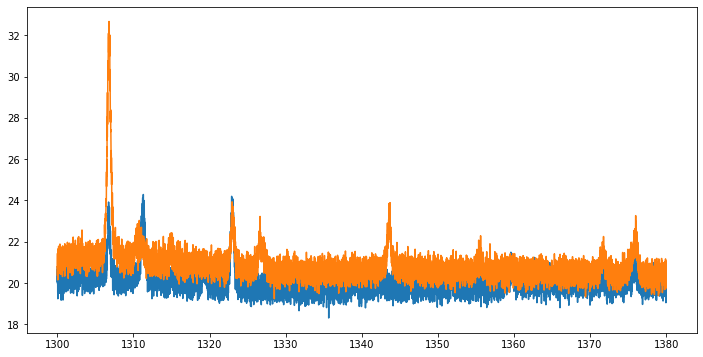

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(freq, T2p[200])

(10485, 2)


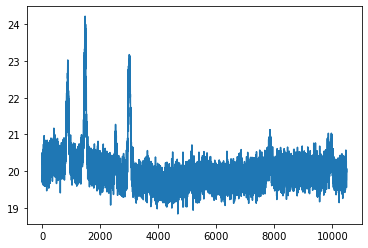

In [ ]:
spec = np.mean(T2p[200:202], axis=0, dtype='float64')
print(spec.shape)

# 用 XX 偏振
spec = spec[:,0]
plt.plot(spec)

(-0.5, 1.0)

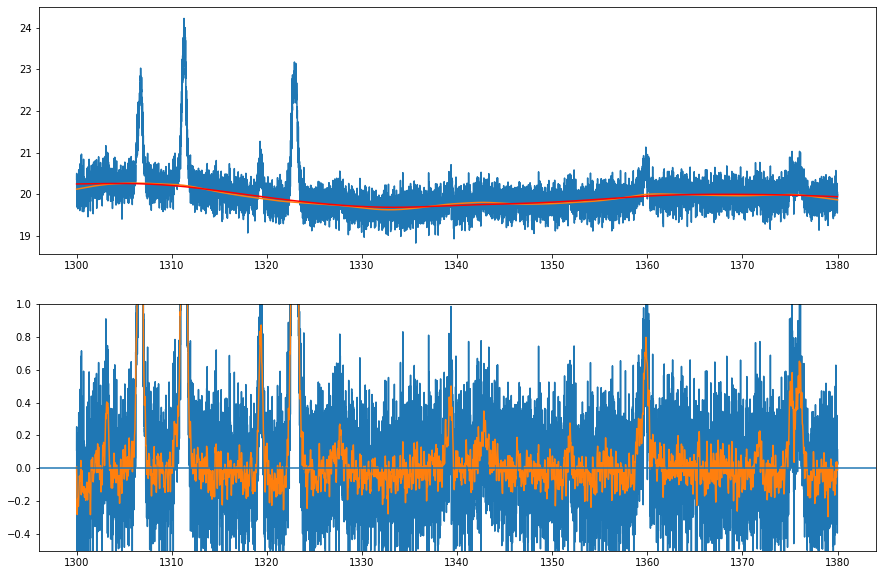

In [ ]:
# fit
method= 'arPLS'
bl_para={}
bl_para['lam']= 1e8
bl_para['deg']= 2
bl_para['niter']= 400
bl_para['ratio']= 0.001

fig,axs= plt.subplots(2,1,figsize=(15,10),)
bl1 = get_baseline(freq, spec, axis=0, average_every=2, method=method, bl_para=bl_para, verbose=False)
method= 'asPLS'
bl_para['lam']= 1e12
#bl_para['offset']= 0.5
bl2 = get_baseline(freq, spec, axis=0, average_every=None, method=method, bl_para=bl_para, verbose=False)
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
ax.plot(freq, bl2,'r')
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl2)
ax.plot(freq, ndimage.gaussian_filter1d(spec-bl2,3))
ax.axhline(y=0)
ax.set_ylim(-0.5,1)

In [ ]:
import pybaselines

In [ ]:
pybaselines.whittaker.arpls(spec, lam=1e7, max_iter=200,)[0]

array([20.05610012, 20.05650895, 20.0569178 , ..., 19.88395249,
       19.88413156, 19.88431064])

In [ ]:
method= 'arPLS'
bl_para={}
bl_para['lam']= 1e7
bl_para['deg']= 2
bl_para['niter']= 200
bl_para['ratio']= 0.01
get_baseline(freq, spec, axis=0, average_every=2, method=method, bl_para=bl_para, verbose=False)

array([20.08624974, 20.08680773, 20.08736571, ..., 19.86522335,
       19.86503201, 19.86477689])

<ipython-input-5-f5ecf24a0d5a>:50: RuntimeWarning: invalid value encountered in double_scalars
  ratio_fit= norm(w-wt)/norm(w)


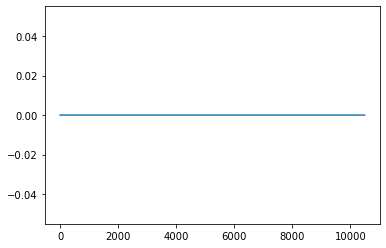

In [ ]:
plt.plot(get_baseline(freq, np.full(len(spec),np.nan), axis=0, average_every=2, method=method, bl_para=bl_para, verbose=False))

(-0.5, 1.0)

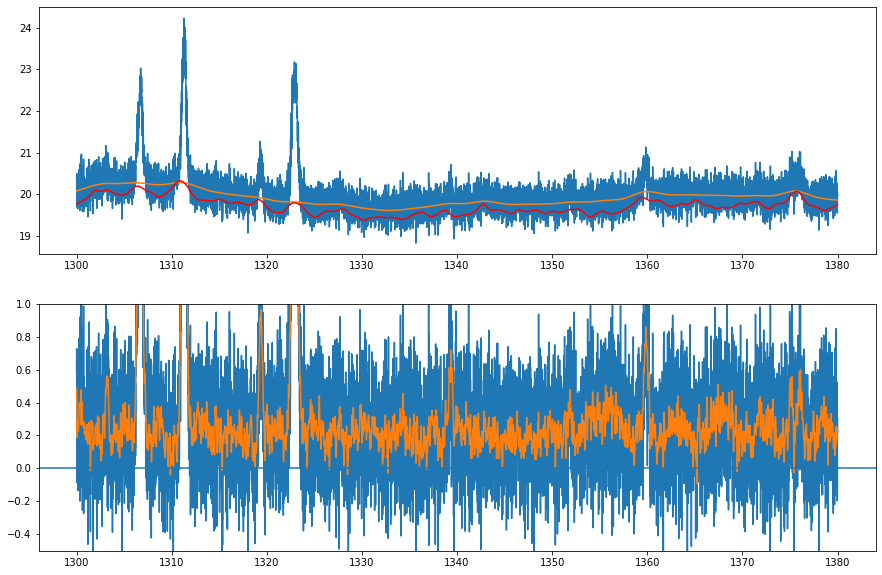

In [ ]:
# fit
method= 'arPLS'
bl_para={}
bl_para['lam']= 1e7
bl_para['deg']= 2
bl_para['niter']= 400
bl_para['ratio']= 0.001

fig,axs= plt.subplots(2,1,figsize=(15,10),)
bl1 = get_baseline(freq, spec, axis=0, average_every=2, method=method, bl_para=bl_para, verbose=False)
method= 'asPLS'
bl_para['lam']= 1e8
bl2 = pybaselines.whittaker.aspls(spec, lam=1e7, max_iter=200,)[0]
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
ax.plot(freq, bl2,'r')
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl2)
ax.plot(freq, ndimage.gaussian_filter1d(spec-bl2,3))
ax.axhline(y=0)
ax.set_ylim(-0.5,1)

CPU 0: 100%|██████████| 1/1.0 [00:00<00:00,  3.93it/s]


(1300.0, 1340.0)

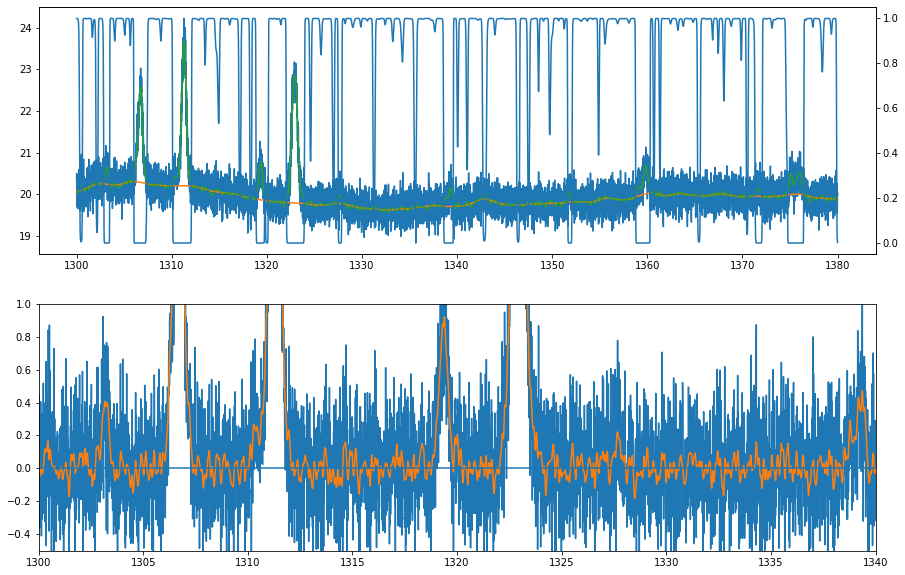

In [ ]:
# fit
method= 'asPLS'
bl_para={}
bl_para['lam'] = 1e9
bl_para['deg'] = 2
bl_para['niter'] = 100
bl_para['ratio'] = 0.01

s_method = 'fft'
s_sigma = 0.5

fig, axs = plt.subplots(2,1,figsize=(15,10),)
bl1_res = get_baseline(freq, spec, axis=0, average_every=None, method=method, bl_para=bl_para, 
                    s_method=s_method, s_sigma=s_sigma,
                      verbose=True, return_f=True,)
bl1 = bl1_res[0]
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
ax.plot(freq, bl1_res[1])
ax = ax.twinx()
ax.plot(freq, bl1_res[3])
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl1)
ax.plot(freq, ndimage.gaussian_filter1d(spec-bl1,4))
ax.axhline(y=0)
ax.set_ylim(-0.5,1)
ax.set_xlim(1300,1340)

In [ ]:
# class SubBaseline():
#     def __init__(self, freq, njoin, method, para, exclude_fun=None, s_method_t=None, s_sigma_t=3, verbose=True, nproc=1):
#         """
#         freq: array, shape:(n,) ; Frequency. 
#         yss: array, shape:(m,n,2)
#         njoin: int
#         method: str; baseline fitting method
#         para: dict; para for method
#         exclude_fun:
#         s_method_t: smooth method along axis 0
#         s_sigma_t:



#         """
#         self.freq = freq
#         self.njoin = njoin
#         self.method = method
#         self.para = para
#         self.exclude_fun = exclude_fun
#         self.s_method_t = s_method_t
#         self.s_sigma_t = s_sigma_t
#         self.verbose = verbose
#         self.nproc = nproc
#     def 

In [ ]:
get_baseline

<function __main__.get_baseline(x, ys, axis=None, *, s_method=None, s_sigma=None, average_every=None, exclude=None, verbose=False, method='arPLS', bl_para=None, return_f=False, check=True)>

In [ ]:
#export
def sub(freq, yss, *, njoin=None, nproc=1, exclude_fun=None, s_method_t=None, s_sigma_t=None,
        **kwargs):
    
    """
    freq: array, shape:(n,) ; Frequency. 
    yss: array, shape:(m,n,2)
    
    njoin: int
    method: str; baseline fitting method
    para: dict; para for method
    exclude_fun:
    s_method_t: smooth method along axis 0
    s_sigma_t:
    **kwargs: args in get_baseline_mp, not includes "exclude" and "return_f"
    """
    
    #global freq, verbose, nproc
    yss_ori = yss
    
    if s_method_t is not None and s_sigma_t is not None:
        if s_method_t in ['boxcar', 'gaussian', 'median']:
            yss = smooth1d(yss, s_method_t, s_sigma_t, axis=0)
        elif s_method_t == 'fft':
            yss = smooth1d_fft(np.arange(yss.shape[0]), yss, s_sigma_t, axis=0)
        else:
            raise(ValueError('not support the method'))
    def apply(yss):
        if njoin is not None:
            shape_add = yss.shape[1:]
            yss = yss.reshape((-1,njoin) + shape_add)
            yssm = np.nanmean(yss, axis=1)
        else:
            yssm = yss
        if exclude_fun is not None:
            exclude = exclude_fun(yssm)
        else:
            exclude = None
        if 's_method' in kwargs.keys():
            if kwargs['s_method'] == 'PLS':
                # use arPLS, lam from s_sigma ( s_sigma_freq)
                yssm = get_baseline_mp(nproc, freq, yssm, axis=1, method='arPLS', bl_para={'lam': para['s_sigma'], "offset":2, 'deg':2}, verbose=verbose)
                kwargs['s_method'] = None
        bls = get_baseline_mp(nproc, freq, yssm, axis=1, exclude=exclude, **kwargs)

        if njoin is not None: 
            return (yss - bls[:, None, :, :]).reshape((-1,) + shape_add)
        else:
            return yss_ori - bls

    if njoin is not None:
        num = len(yss)//njoin*njoin
        if num != len(yss):
            return np.vstack([apply(yss[:num]), apply(yss[-njoin:])[num-len(yss):]])
        else:
            return apply(yss)
    else:
        return apply(yss)

In [ ]:
T2p.shape, freq.shape

((8192, 10485, 2), (10485,))

In [ ]:
bl_para={}
bl_para['lam'] = 1e9
bl_para['deg'] = 2
bl_para['niter'] = 500
bl_para['ratio'] = 0.01

s_method_freq = 'fft'
s_sigma_freq = 0.5
average_every_freq = None

method = 'arPLS'
verbose = True

In [ ]:
para = {
        's_method': s_method_freq,
        's_sigma': s_sigma_freq,
        'average_every': average_every_freq,
        'bl_para': bl_para,
        'verbose': verbose
}
   

In [ ]:
njoin_t = 10
s_method_t = None
s_sigma_t = None
nproc = 10

In [ ]:
s_method_t

In [ ]:
T = sub(freq, T2p[:], njoin=njoin_t, nproc=nproc, method=method, s_method_t=s_method_t, s_sigma_t=s_sigma_t, **para)

CPU 0: 100%|██████████| 164/164.0 [00:41<00:00,  3.99it/s]
CPU 0: 100%|██████████| 2/2.0 [00:00<00:00,  4.31it/s]


In [ ]:
T = sub(freq, T2p[:], njoin=njoin_t, nproc=nproc, method=method, s_method_t=s_method_t, s_sigma_t=s_sigma_t, **para)

CPU 0: 100%|██████████| 164/164.0 [00:15<00:00, 10.84it/s]
CPU 0: 100%|██████████| 2/2.0 [00:00<00:00,  6.63it/s]


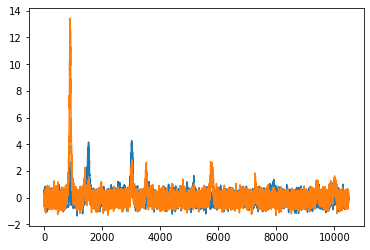

In [ ]:
plt.plot(T[0])